# 08 — Recommendation Analysis
## What are we actually recommending?

**Goal:**
Analyse the output of our recommendation system.
Understand diversity, coverage, and personalisation quality.

**Questions:**
1. How diverse are recommendations across users?
2. What fraction of the catalogue do we actually recommend?
3. Is personalisation real or are all users getting the same list?
4. What is the novelty of our recommendations?

In [12]:
import pandas as pd
import numpy as np
import pickle
import os
import json
import warnings
from datetime import datetime
from collections import Counter
import matplotlib.pyplot as plt 
from tqdm import tqdm
import sys
import torch

print("Libraries loaded.")
print(f"Run started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Libraries loaded.
Run started: 2026-04-09 23:03:22


In [2]:
#Getting the project root path 
BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, "data")
PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "processed")
MODELS_DIR = os.path.join(BASE_DIR, "models")
PLOT_DIR = os.path.join(PROCESSED_DATA_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

print(f"Base directory: {BASE_DIR}")

Base directory: c:\Projects\Cinemate V2


In [13]:
#Load processed directories
print("Loading preprocessed file...............")

train = pd.read_parquet(os.path.join(PROCESSED_DATA_DIR, "train.parquet"))
test = pd.read_parquet(os.path.join(PROCESSED_DATA_DIR, "test.parquet"))
movies_clean = pd.read_parquet(os.path.join(PROCESSED_DATA_DIR, "movies_clean.parquet"))
with open(os.path.join(PROCESSED_DATA_DIR, "user_positive_sets.pkl") , "rb") as f:
    user_positive_sets = pickle.load(f)

with open(os.path.join(PROCESSED_DATA_DIR, "dataset_constants.pkl"), "rb") as f:
    constants = pickle.load(f)

EMBED_PATH = os.path.join(PROCESSED_DATA_DIR, "content_embeddings.pt")
content_embeddings = torch.load(EMBED_PATH, map_location="cpu")

NUM_USERS = constants['NUM_USERS']
NUM_MOVIES = constants['NUM_MOVIES']


Loading preprocessed file...............


In [17]:
import torch
sys.path.append(os.path.dirname(os.getcwd()))
from src.hybrid_model import TwoTowerModel


DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Load model
embed_path  = os.path.join(
    PROCESSED_DATA_DIR, "content_embeddings.pt"
)
content_emb = torch.load(embed_path, map_location='cpu')

model = TwoTowerModel(
    num_users                 = NUM_USERS,
    num_movies                = NUM_MOVIES,
    content_embedding_matrix = content_embeddings,
    embed_dim                 = 128,
    tower_output_dim          = 64,
    dropout                   = 0.0
).to(DEVICE)

ckpt = torch.load(
    os.path.join(MODELS_DIR, "two_tower_best.pt"),
    map_location=DEVICE
)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Model loaded from epoch {ckpt['epoch']}")

# Generate recommendations for 500 sample users
N_SAMPLE   = 500
TOP_K      = 10
all_movies = torch.arange(NUM_MOVIES).to(DEVICE)

test_relevant = (
    test[test['rating'] >= 3.5]
    .groupby('user_idx')['movie_idx']
    .apply(set)
    .to_dict()
)
eval_users = list(test_relevant.keys())[:N_SAMPLE]

print(f"Generating recs for {N_SAMPLE} users...")
user_recs = {}

with torch.no_grad():
    for user_idx in tqdm(eval_users):
        seen = user_positive_sets.get(user_idx, set())
        u_t  = torch.full(
            (NUM_MOVIES,), user_idx, dtype=torch.long
        ).to(DEVICE)
        scores = model(u_t, all_movies).cpu().numpy()
        for m in seen:
            if m < len(scores):
                scores[m] = -np.inf
        top_k = np.argsort(scores)[::-1][:TOP_K].tolist()
        user_recs[user_idx] = top_k

print(f"Generated {len(user_recs)} recommendation lists")

Model loaded from epoch 50
Generating recs for 500 users...


100%|██████████| 500/500 [00:13<00:00, 35.93it/s]

Generated 500 recommendation lists


### Catalogue Coverage

In [18]:
print("=" * 55)
print("1. CATALOGUE COVERAGE")
print("=" * 55)

all_recommended = set()
for recs in user_recs.values():
    all_recommended.update(recs)

coverage = len(all_recommended) / NUM_MOVIES
print(f"Unique movies recommended  : {len(all_recommended):,}")
print(f"Total movies in catalogue  : {NUM_MOVIES:,}")
print(f"Catalogue coverage         : {coverage:.2%}")
print()

# How many movies NEVER recommended?
never_recommended = NUM_MOVIES - len(all_recommended)
print(f"Movies never recommended   : {never_recommended:,} "
      f"({never_recommended/NUM_MOVIES:.1%})")
print()
print("Interpretation:")
if coverage < 0.10:
    print("  LOW coverage — strong popularity bias")
    print("  Most recommendations come from small set of popular films")
elif coverage < 0.30:
    print("  MEDIUM coverage — some diversity but popularity bias present")
else:
    print("  GOOD coverage — model recommends diverse catalogue")

1. CATALOGUE COVERAGE
Unique movies recommended  : 221
Total movies in catalogue  : 27,766
Catalogue coverage         : 0.80%

Movies never recommended   : 27,545 (99.2%)

Interpretation:
  LOW coverage — strong popularity bias
  Most recommendations come from small set of popular films


In [19]:
os.path.dirname(os.getcwd())

'c:\\Projects\\Cinemate V2'

### Personalisation Score

2. PERSONALISATION SCORE

If all users get the same recommendations →
personalisation score = 0 (no personalisation)
If all users get completely different recommendations →
personalisation score = 1 (perfect personalisation)

Mean Jaccard similarity    : 0.1369
Personalisation score      : 0.8631

HIGH personalisation — users get meaningfully different recs


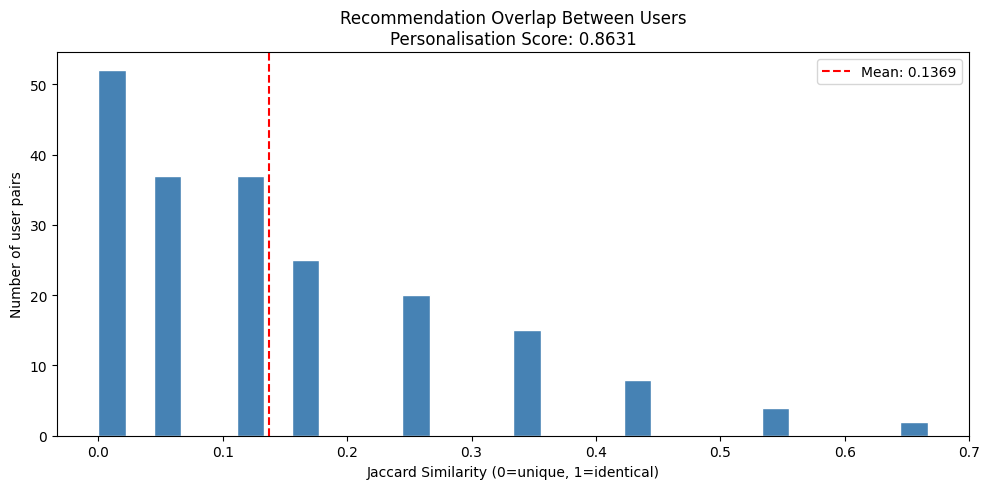

In [21]:
print("=" * 55)
print("2. PERSONALISATION SCORE")
print("=" * 55)
print()
print("If all users get the same recommendations →")
print("personalisation score = 0 (no personalisation)")
print("If all users get completely different recommendations →")
print("personalisation score = 1 (perfect personalisation)")
print()

# Pairwise Jaccard dissimilarity
# Sample 200 pairs of users
user_list = list(user_recs.keys())
n_pairs   = 200
jaccard_scores = []

for _ in range(n_pairs):
    i, j = np.random.choice(len(user_list), 2, replace=False)
    u1    = set(user_recs[user_list[i]])
    u2    = set(user_recs[user_list[j]])
    intersection = len(u1 & u2)
    union        = len(u1 | u2)
    jaccard      = intersection / union if union > 0 else 0
    jaccard_scores.append(jaccard)

# Personalisation = 1 - mean(Jaccard similarity)
personalisation = 1 - np.mean(jaccard_scores)

print(f"Mean Jaccard similarity    : {np.mean(jaccard_scores):.4f}")
print(f"Personalisation score      : {personalisation:.4f}")
print()

if personalisation > 0.7:
    print("HIGH personalisation — users get meaningfully different recs")
elif personalisation > 0.4:
    print("MEDIUM personalisation — some variation between users")
else:
    print("LOW personalisation — popularity bias dominates")

# Distribution of overlap
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(jaccard_scores, bins=30,
        color='steelblue', edgecolor='white')
ax.axvline(np.mean(jaccard_scores), color='red',
           linestyle='--',
           label=f'Mean: {np.mean(jaccard_scores):.4f}')
ax.set_xlabel('Jaccard Similarity (0=unique, 1=identical)')
ax.set_ylabel('Number of user pairs')
ax.set_title(f'Recommendation Overlap Between Users\n'
             f'Personalisation Score: {personalisation:.4f}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,
            '14_personalisation.png'),
            dpi=150, bbox_inches='tight')
plt.show()

3. GENRE DIVERSITY PER USER
Avg unique genres per user : 11.7
Min unique genres          : 7
Max unique genres          : 16



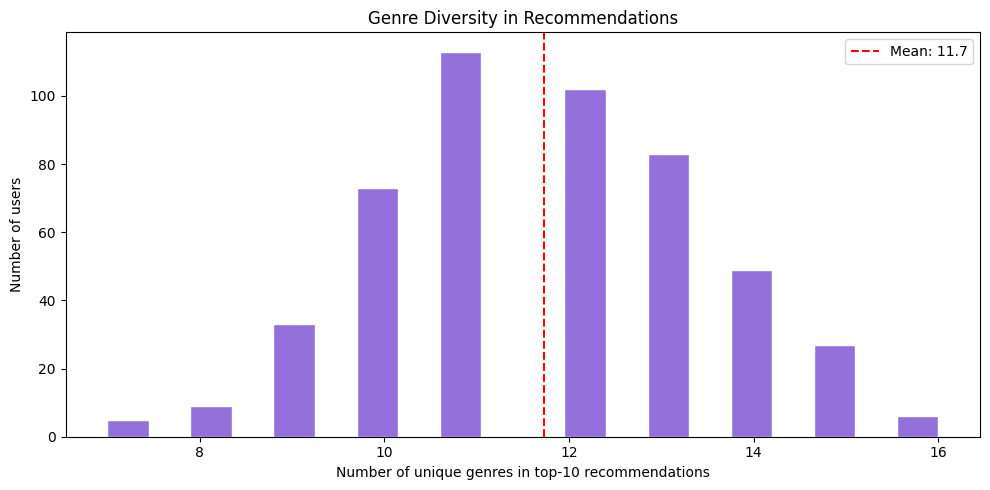

In [22]:
print("=" * 55)
print("3. GENRE DIVERSITY PER USER")
print("=" * 55)

movie_genres = movies_clean.set_index(
    'movie_idx'
)['genres_clean'].to_dict()

user_genre_counts = []
for user_idx, recs in user_recs.items():
    genres = set()
    for m in recs:
        g = movie_genres.get(m, '')
        if g:
            genres.update(g.split())
    user_genre_counts.append(len(genres))

print(f"Avg unique genres per user : "
      f"{np.mean(user_genre_counts):.1f}")
print(f"Min unique genres          : "
      f"{min(user_genre_counts)}")
print(f"Max unique genres          : "
      f"{max(user_genre_counts)}")
print()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(user_genre_counts, bins=20,
        color='mediumpurple', edgecolor='white')
ax.axvline(np.mean(user_genre_counts), color='red',
           linestyle='--',
           label=f'Mean: {np.mean(user_genre_counts):.1f}')
ax.set_xlabel('Number of unique genres in top-10 recommendations')
ax.set_ylabel('Number of users')
ax.set_title('Genre Diversity in Recommendations')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,
            '15_genre_diversity.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [23]:
rec_analysis = {
    "n_sample_users"       : N_SAMPLE,
    "top_k"                : TOP_K,
    "catalogue_coverage"   : float(coverage),
    "unique_movies_rec"    : int(len(all_recommended)),
    "never_recommended"    : int(never_recommended),
    "personalisation_score": float(personalisation),
    "mean_jaccard"         : float(np.mean(jaccard_scores)),
    "avg_genres_per_user"  : float(np.mean(user_genre_counts)),
    "timestamp"            : datetime.now().strftime(
        '%Y-%m-%d %H:%M:%S'
    )
}

path = os.path.join(MODELS_DIR, "rec_analysis.json")
with open(path, "w") as f:
    json.dump(rec_analysis, f, indent=2)

print("=" * 55)
print("RECOMMENDATION ANALYSIS SUMMARY")
print("=" * 55)
for k, v in rec_analysis.items():
    if k != 'timestamp':
        print(f"  {k:<30s}: {v}")

RECOMMENDATION ANALYSIS SUMMARY
  n_sample_users                : 500
  top_k                         : 10
  catalogue_coverage            : 0.007959374774904559
  unique_movies_rec             : 221
  never_recommended             : 27545
  personalisation_score         : 0.863070024231015
  mean_jaccard                  : 0.13692997576898505
  avg_genres_per_user           : 11.734
